# Beginner PCA: Wine Quality Visualisation

## Project Goal

This notebook applies **Principal Component Analysis (PCA)** to the Wine Quality dataset.

The goal is to reduce many wine chemistry features into **2 or 3 principal components** so that the dataset can be visualised more easily.

PCA helps us answer questions such as:

- Can wine samples be represented in a simpler 2D or 3D space?
- Do different wine quality classes show any visible separation?
- How much variance is captured by the first principal components?

---

## Dataset

**Dataset:** Wine Quality  
**Source:** Kaggle / UCI Wine Quality dataset  
**Target variable:** `quality`

The input features are chemical properties of wine, such as:

- fixed acidity
- volatile acidity
- citric acid
- residual sugar
- chlorides
- free sulfur dioxide
- total sulfur dioxide
- density
- pH
- sulphates
- alcohol

---

## PCA Concepts Used

This notebook focuses on the beginner-level PCA workflow:

1. Load and inspect the dataset
2. Separate input features `X` and target `y`
3. Standardise the input features
4. Apply PCA with `n_components=2`
5. Visualise the data using PC1 and PC2
6. Calculate explained variance ratio
7. Plot explained variance as a bar chart
8. Apply PCA with `n_components=3`
9. Create a 3D PCA scatter plot
10. Interpret the results

---

## Important Note

PCA is an **unsupervised** dimensionality reduction method.

This means PCA does not use the `quality` column while creating the principal components.  
The `quality` column is used only later to colour the scatter plots and visually inspect whether quality classes show separation.

In [1]:
# Core libraries
import os
import time
import warnings

# Data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Machine learning preprocessing and PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 3D plotting
from mpl_toolkits.mplot3d import Axes3D

# Display settings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the Wine Quality red wine dataset directly from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

wine = pd.read_csv(url, sep=";")

print("Dataset loaded successfully.")
print("Shape:", wine.shape)

wine.head()

Dataset loaded successfully.
Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# Basic overview of the dataset
print("First 5 rows:")
display(wine.head())

print("\nColumn names:")
print(wine.columns.tolist())

print("\nDataset information:")
wine.info()

print("\nMissing values per column:")
display(wine.isna().sum())

print("\nBasic statistical summary:")
display(wine.describe().T)

First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



Column names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality         

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


Basic statistical summary:


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


## Separating Features and Target Variable

Before applying PCA, the dataset must be divided into input features and the target variable.

In this notebook:

* `X` contains the wine chemistry features used as input for PCA.
* `y` contains the wine `quality` values.

PCA is an unsupervised dimensionality reduction method, so it only uses the input features in `X`. The target variable `quality` is not used to calculate the principal components. It will only be used later to colour the PCA scatter plots and visually inspect whether wine quality classes show any separation.


In [4]:
# Separate input features and target variable
X = wine.drop(columns=["quality"])
y = wine["quality"]

print("Feature matrix X shape:", X.shape)
print("Target y shape:", y.shape)

print("\nInput features:")
print(X.columns.tolist())

print("\nTarget classes:")
print(sorted(y.unique()))

Feature matrix X shape: (1599, 11)
Target y shape: (1599,)

Input features:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Target classes:
[3, 4, 5, 6, 7, 8]


## Conclusion

The dataset has been successfully separated into input features and the target variable.

The feature matrix `X` contains the chemical properties of the wines, while `y` contains the wine quality labels. These quality labels will not be used by PCA during dimensionality reduction. Instead, they will be used later only for colouring and interpreting the PCA visualisations.

This separation is important because PCA should learn the structure of the input data independently, without using the target labels.


## Standardising the Input Features

PCA is sensitive to the scale of the input features. This means that features with larger numeric ranges can dominate the principal components, even if they are not necessarily more important.

For example, in the Wine Quality dataset, `total sulfur dioxide` may have much larger values than `pH`. Without standardisation, PCA may give more importance to `total sulfur dioxide` simply because its numbers are larger.

To avoid this problem, the input features are standardised using `StandardScaler`.

After standardisation:

* each feature has a mean close to 0
* each feature has a standard deviation close to 1
* all features are placed on a comparable scale

Only the input features `X` are standardised. The target variable `quality` is not standardised because it is used only for colouring and interpretation.


In [5]:
# Standardise the input features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert the scaled array back into a DataFrame for easier inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Standardisation completed.")
print("Shape of scaled feature matrix:", X_scaled_df.shape)

print("\nMean of each scaled feature:")
display(X_scaled_df.mean().round(3))

print("\nStandard deviation of each scaled feature:")
display(X_scaled_df.std().round(3))

X_scaled_df.head()

Standardisation completed.
Shape of scaled feature matrix: (1599, 11)

Mean of each scaled feature:


fixed acidity           0.0
volatile acidity        0.0
citric acid            -0.0
residual sugar         -0.0
chlorides               0.0
free sulfur dioxide    -0.0
total sulfur dioxide    0.0
density                -0.0
pH                      0.0
sulphates               0.0
alcohol                 0.0
dtype: float64


Standard deviation of each scaled feature:


fixed acidity           1.0
volatile acidity        1.0
citric acid             1.0
residual sugar          1.0
chlorides               1.0
free sulfur dioxide     1.0
total sulfur dioxide    1.0
density                 1.0
pH                      1.0
sulphates               1.0
alcohol                 1.0
dtype: float64

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246
1,-0.298547,1.967442,-1.391472,0.043416,0.223875,0.872638,0.624363,0.028261,-0.719933,0.128950,-0.584777
2,-0.298547,1.297065,-1.186070,-0.169427,0.096353,-0.083669,0.229047,0.134264,-0.331177,-0.048089,-0.584777
3,1.654856,-1.384443,1.484154,-0.453218,-0.264960,0.107592,0.411500,0.664277,-0.979104,-0.461180,-0.584777
4,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246


## Conclusion

The input features have been successfully standardised.

This step ensures that all wine chemistry variables are measured on a comparable scale before PCA is applied. Standardisation is important because PCA looks for directions with the largest variance, and features with larger raw numeric ranges could otherwise dominate the result unfairly.

The scaled feature matrix keeps the same number of rows and columns as the original input data, but the values have been transformed so that each feature has approximately mean 0 and standard deviation 1.


## Applying PCA with 2 Components

After standardising the input features, PCA can now be applied.

In this step, the original wine chemistry features are reduced into two new variables:

* `PC1`: the first principal component, which captures the largest direction of variance
* `PC2`: the second principal component, which captures the second-largest direction of variance

These two components create a simplified 2D view of the dataset.

The wine `quality` column is not used to calculate PCA. It is only used to colour the scatter plot so that we can visually inspect whether different quality classes show separation or overlap.


PCA with 2 components completed.
PCA DataFrame shape: (1599, 3)

Explained variance ratio:
PC1: 0.2817
PC2: 0.1751
Total explained variance: 0.4568


,PC1,PC2,quality
0,-1.619530,0.450950,5
1,-0.799170,1.856553,5
2,-0.748479,0.882039,5
3,2.357673,-0.269976,6
4,-1.619530,0.450950,5


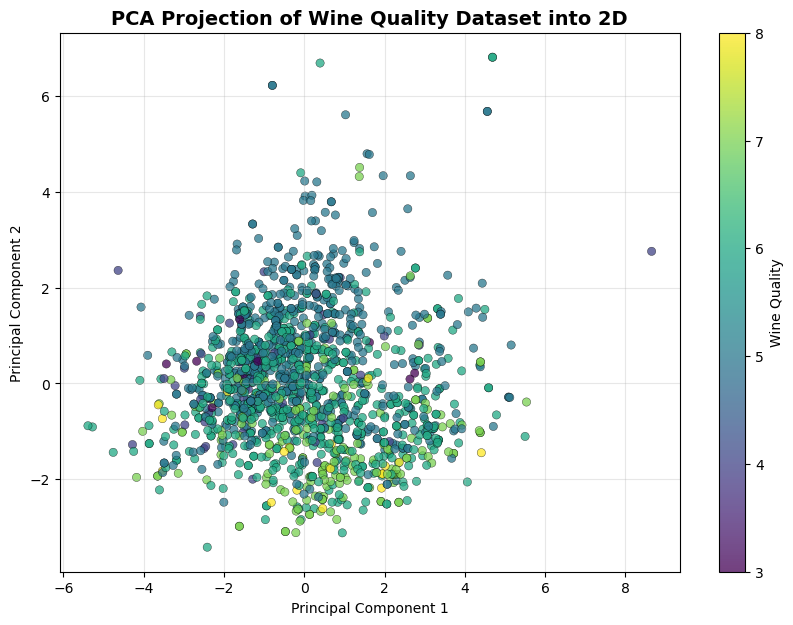

In [6]:
# Apply PCA with 2 components
pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_scaled_df)

# Create a DataFrame with PCA results
pca_2d_df = pd.DataFrame(
    data=X_pca_2d,
    columns=["PC1", "PC2"]
)

# Add quality labels for visualisation
pca_2d_df["quality"] = y.values

print("PCA with 2 components completed.")
print("PCA DataFrame shape:", pca_2d_df.shape)

print("\nExplained variance ratio:")
print("PC1:", round(pca_2d.explained_variance_ratio_[0], 4))
print("PC2:", round(pca_2d.explained_variance_ratio_[1], 4))
print("Total explained variance:", round(pca_2d.explained_variance_ratio_.sum(), 4))

display(pca_2d_df.head())

# 2D PCA scatter plot
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    pca_2d_df["PC1"],
    pca_2d_df["PC2"],
    c=pca_2d_df["quality"],
    cmap="viridis",
    alpha=0.75,
    edgecolor="k",
    linewidth=0.3
)

plt.title("PCA Projection of Wine Quality Dataset into 2D", fontsize=14, fontweight="bold")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

cbar = plt.colorbar(scatter)
cbar.set_label("Wine Quality")

plt.grid(alpha=0.3)
plt.show()

## Conclusion

The 2D PCA scatter plot shows the Wine Quality dataset projected onto the first two principal components.

The first two components explain **45.68%** of the total variance, which means the plot gives a useful simplified view of the data, but it does not capture the full structure of the original feature space.

The wine quality classes show a strong amount of overlap, especially for the common quality values such as 5 and 6. This suggests that the first two principal components do not clearly separate the wine quality classes.

This result is expected because PCA is unsupervised. It does not use the `quality` column while creating the components. The quality labels are used only for colouring the plot after PCA has already transformed the data.

## Conclusion

PCA with two components has been successfully applied to the standardised Wine Quality dataset.

The original wine chemistry features have been transformed into two principal components: `PC1` and `PC2`. These components provide a simplified 2D representation of the data.

The scatter plot shows each wine sample in the new PCA space, with colours representing the original wine quality classes. Since PCA is unsupervised, the quality labels were not used to create the components. They are used only for visual interpretation.

If the quality colours form clear regions, this suggests that the chemical features contain some structure related to wine quality. If the colours overlap strongly, it means that wine quality is not cleanly separated in the first two principal components.


## Conclusion

PCA with two components was successfully applied to the standardised Wine Quality dataset.

The first principal component, `PC1`, explains **28.17%** of the total variance, while the second principal component, `PC2`, explains **17.51%**. Together, the first two components explain **45.68%** of the original dataset variance.

This means the 2D PCA plot provides a useful simplified view of the wine chemistry data, but it does not capture the full structure of the dataset. More than half of the total variance is still contained in the remaining components.

The quality labels were used only for colouring the scatter plot. Since PCA is unsupervised, the quality column was not used to calculate the principal components. If the quality classes overlap in the plot, this suggests that the first two principal components do not fully separate wine quality levels.


## Applying PCA with 3 Components

In the previous step, PCA was applied with two components to create a 2D visualisation. Now PCA will be applied with three components.

The three new components are:

* `PC1`: captures the largest direction of variance
* `PC2`: captures the second-largest direction of variance
* `PC3`: captures the third-largest direction of variance

Using three components allows us to visualise the dataset in 3D. This can sometimes show additional structure that is not visible in the 2D PCA plot.

As before, the wine `quality` column is not used to calculate PCA. It is only used to colour the points in the 3D scatter plot.


PCA with 3 components completed.
PCA DataFrame shape: (1599, 4)

Explained variance ratio:
PC1: 0.2817
PC2: 0.1751
PC3: 0.141
Total explained variance: 0.5978


,PC1,PC2,PC3,quality
0,-1.619530,0.450950,-1.774454,5
1,-0.799170,1.856553,-0.911690,5
2,-0.748479,0.882039,-1.171394,5
3,2.357673,-0.269976,0.243489,6
4,-1.619530,0.450950,-1.774454,5


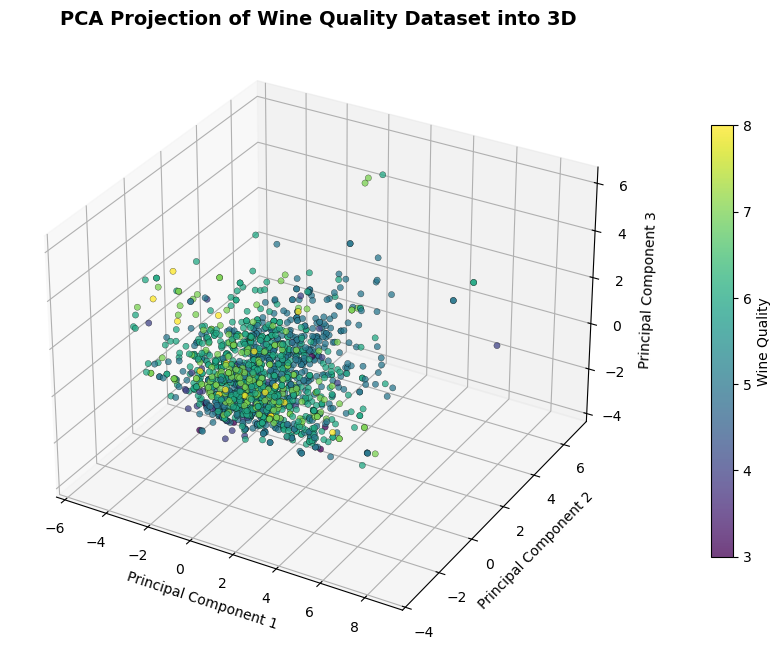

In [7]:
# Apply PCA with 3 components
pca_3d = PCA(n_components=3)

X_pca_3d = pca_3d.fit_transform(X_scaled_df)

# Create a DataFrame with PCA results
pca_3d_df = pd.DataFrame(
    data=X_pca_3d,
    columns=["PC1", "PC2", "PC3"]
)

# Add quality labels for visualisation
pca_3d_df["quality"] = y.values

print("PCA with 3 components completed.")
print("PCA DataFrame shape:", pca_3d_df.shape)

print("\nExplained variance ratio:")
print("PC1:", round(pca_3d.explained_variance_ratio_[0], 4))
print("PC2:", round(pca_3d.explained_variance_ratio_[1], 4))
print("PC3:", round(pca_3d.explained_variance_ratio_[2], 4))
print("Total explained variance:", round(pca_3d.explained_variance_ratio_.sum(), 4))

display(pca_3d_df.head())

# 3D PCA scatter plot
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    pca_3d_df["PC1"],
    pca_3d_df["PC2"],
    pca_3d_df["PC3"],
    c=pca_3d_df["quality"],
    cmap="viridis",
    alpha=0.75,
    edgecolor="k",
    linewidth=0.25
)

ax.set_title("PCA Projection of Wine Quality Dataset into 3D", fontsize=14, fontweight="bold")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")

cbar = fig.colorbar(scatter, ax=ax, shrink=0.7, pad=0.1)
cbar.set_label("Wine Quality")

plt.show()

## Conclusion

PCA with three components was successfully applied to the standardised Wine Quality dataset.

The first three principal components explain the following amount of variance:

- `PC1`: **28.17%**
- `PC2`: **17.51%**
- `PC3`: **14.10%**

Together, the first three components explain **59.78%** of the total variance in the original standardised wine chemistry features.

Compared with the 2D PCA plot, the 3D PCA plot captures more information because it includes one additional principal component. The 2D plot captured **45.68%** of the variance, while the 3D plot captures **59.78%**.

However, the wine quality classes still show a noticeable amount of overlap. This suggests that even the first three principal components do not fully separate the wine quality levels.

This result is expected because PCA is unsupervised. The `quality` column was not used when calculating the principal components. It was used only for colouring the points in the 3D scatter plot.

## Comparing 2D and 3D PCA Variance

The 2D PCA projection uses only the first two principal components, while the 3D PCA projection uses the first three principal components.

Since the 3D version includes one additional component, it should capture more total variance than the 2D version.

In this step, the total explained variance of the 2D and 3D PCA representations is compared directly.


,PCA Representation,Number of Components,Total Explained Variance (%)
0,2D PCA (PC1 + PC2),2,45.682201
1,3D PCA (PC1 + PC2 + PC3),3,59.778051


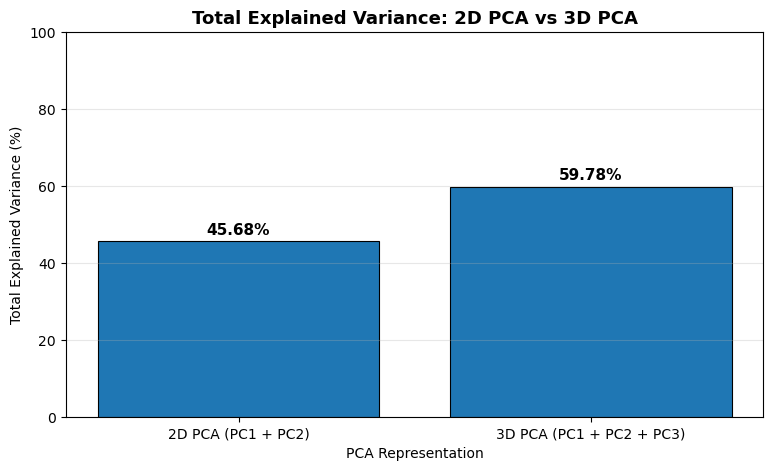

In [8]:
# Compare total explained variance for 2D and 3D PCA
pca_comparison_df = pd.DataFrame({
    "PCA Representation": ["2D PCA (PC1 + PC2)", "3D PCA (PC1 + PC2 + PC3)"],
    "Number of Components": [2, 3],
    "Total Explained Variance (%)": [
        pca_2d.explained_variance_ratio_.sum() * 100,
        pca_3d.explained_variance_ratio_.sum() * 100
    ]
})

display(pca_comparison_df)

# Bar chart comparison
plt.figure(figsize=(9, 5))

bars = plt.bar(
    pca_comparison_df["PCA Representation"],
    pca_comparison_df["Total Explained Variance (%)"],
    edgecolor="black",
    linewidth=0.8
)

plt.title("Total Explained Variance: 2D PCA vs 3D PCA", fontsize=13, fontweight="bold")
plt.xlabel("PCA Representation")
plt.ylabel("Total Explained Variance (%)")
plt.ylim(0, 100)

# Add labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.3)
plt.show()

## Conclusion

The comparison confirms that the 3D PCA representation captures more variance than the 2D PCA representation.

The 2D PCA plot, using `PC1` and `PC2`, explains **45.68%** of the total variance. The 3D PCA plot, using `PC1`, `PC2`, and `PC3`, explains **59.78%** of the total variance.

This means that adding the third component helps preserve more of the original dataset structure. However, even with three components, around 40% of the variance remains outside the 3D representation.

Therefore, the 3D PCA plot provides a richer visualisation than the 2D plot, but it is still a simplified view of the original 11-dimensional wine chemistry dataset.


# Final Conclusion

In this notebook, Principal Component Analysis was applied to the Wine Quality dataset for beginner-level dimensionality reduction and visualisation.

The original dataset contained **11 chemical input features** and one target column, `quality`. Since PCA is an unsupervised method, only the chemical input features were used to calculate the principal components. The `quality` column was used only after PCA to colour the scatter plots.

Before applying PCA, the input features were standardised using `StandardScaler`. This was necessary because PCA is sensitive to feature scale, and wine chemistry variables such as `pH`, `alcohol`, and `total sulfur dioxide` are measured on different numeric ranges.

PCA was first applied with two components. The 2D PCA representation showed that:

- `PC1` explained **28.17%** of the total variance
- `PC2` explained **17.51%** of the total variance
- Together, `PC1` and `PC2` explained **45.68%** of the total variance

The 2D scatter plot gave a useful simplified view of the dataset, but the wine quality classes showed strong overlap. This indicates that the first two principal components do not clearly separate the wine quality levels.

PCA was then applied with three components. The 3D PCA representation showed that:

- `PC1` explained **28.17%**
- `PC2` explained **17.51%**
- `PC3` explained **14.10%**
- Together, the first three components explained **59.78%** of the total variance

The 3D PCA plot captured more information than the 2D plot, but the quality classes still showed overlap. This suggests that wine quality is not fully separated by the first three principal components alone.

Overall, PCA was useful for reducing the Wine Quality dataset into a simpler 2D and 3D visual form. However, the results also show that PCA visualisations should be interpreted carefully, because they are simplified views and do not preserve all information from the original feature space.